In [1]:
import sys
sys.path.append("..")

from src.torch.pre_processing.graph_batching import batch_full_events_to_graphs, full_event_to_graphs
from src.plotting.feature_plotting import plot_graph
import matplotlib.pyplot as plt
import numpy as np
import torch

DATA_DIR = "../mu3e_trigger_data"
MODEL_DIR= "../models"
PLOTS_DIR = "../plots"
SIGNAL_PIXEL_FILE = f"{DATA_DIR}/sig_with_layer_pixel_spacetime.npy"
BACKGROUND_PIXEL_FILE = f"{DATA_DIR}/bg_with_layer_pixel_spacetime.npy"
SIGNAL_MPPC_FILE = f"{DATA_DIR}/sig_with_layer_mppc_spacetime.npy"
BACKGROUND_MPPC_FILE = f"{DATA_DIR}/bg_with_layer_mppc_spacetime.npy"
SIGNAL_ONLY_PIXEL_FILE = f"{DATA_DIR}/sig_only_with_layer_pixel_spacetime.npy"
SIGNAL_ONLY_MPPC_FILE = f"{DATA_DIR}/sig_only_with_layer_mppc_spacetime.npy"


bg_pixel_spacetime = np.load(BACKGROUND_PIXEL_FILE)
bg_mppc_spacetime = np.load(BACKGROUND_MPPC_FILE)
sig_pixel_spacetime = np.load(SIGNAL_PIXEL_FILE)
sig_mppc_spacetime = np.load(SIGNAL_MPPC_FILE)
sig_only_pixel_spacetime = np.load(SIGNAL_ONLY_PIXEL_FILE)
sig_only_mppc_spacetime = np.load(SIGNAL_ONLY_MPPC_FILE)


In [2]:
sig_only_mppc_spacetime[0, :, 3]

array([ 2.5,  2.5,  2.5,  2.5,  2.5,  2.5,  2.5,  2.5,  2.5,  2.5,  2.5,
        2.5, -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. ,
       -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. ,
       -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. ,
       -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. ,
       -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. ,
       -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. ,
       -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. ,
       -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. ,
       -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. ,
       -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. ,
       -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. ,
       -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. ,
       -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1

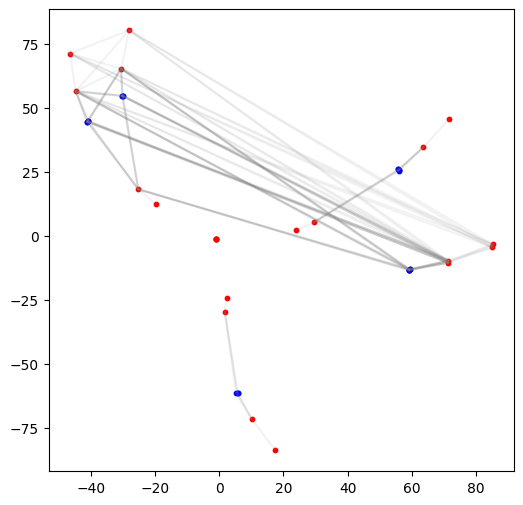

In [3]:
event_id = 2
graphs_bg = full_event_to_graphs(sig_only_mppc_spacetime[event_id:event_id+1], sig_only_pixel_spacetime[event_id:event_id+1], connect_layers=True)
fig, ax = plt.subplots(1, figsize=(6, 6))
mppc_nodes = graphs_bg[0].x[graphs_bg[0].x[:, 3] == 0]
pixel_nodes = graphs_bg[0].x[graphs_bg[0].x[:, 3] == 1]
ax.scatter(mppc_nodes[:, 0], mppc_nodes[:, 1], c='blue', s=10, label='MPPC hits')
ax.scatter(pixel_nodes[:, 0], pixel_nodes[:, 1], c='red', s=10, label='Pixel hits')
for edge_index in range(graphs_bg[0].edge_index.shape[1]):
    edge = graphs_bg[0].edge_index[:, edge_index]
    if graphs_bg[0].edge_labels[edge_index] == 0:
        continue
    ax.plot(
        [graphs_bg[0].x[edge[0], 0], graphs_bg[0].x[edge[1], 0]],
        [graphs_bg[0].x[edge[0], 1], graphs_bg[0].x[edge[1], 1]],
        c="gray",
        alpha=0.1,
    )

In [ ]:
X_pixel = np.concatenate([sig_only_pixel_spacetime, bg_pixel_spacetime], axis=0)
X_mppc = np.concatenate([sig_only_mppc_spacetime, bg_mppc_spacetime], axis=0)
y = np.concatenate(
    [np.ones(sig_only_pixel_spacetime.shape[0]), np.zeros(bg_pixel_spacetime.shape[0])], axis=0
)

from src.torch.pre_processing.graph_batching import (
    batch_full_events_to_graphs)

graphs = batch_full_events_to_graphs(X_mppc, X_pixel, y, connect_layers=True)

graph_size = np.array([g.num_nodes for g in graphs])
graph_labels = np.array([g.y.item() for g in graphs])
x_max = np.percentile(graph_size, 95).astype(int)
x_max = (x_max // 2 + 1) * 2  # Round up to nearest 2
bins = np.linspace(0, x_max, x_max // 2 + 1) 
fig, ax = plt.subplots(figsize=(8, 5), )
ax.hist(
    graph_size[graph_labels == 0],
    bins=bins,
    alpha=0.5,
    label="Background",
    color="blue",
    density=True,
)
ax.hist(
    graph_size[graph_labels == 1],
    bins=bins,
    alpha=0.5,
    label="Signal",
    color="orange",
    density=True,
)
ax.set_xlabel("Number of nodes in graph")
ax.set_ylabel("Density")
ax.set_title("Distribution of graph sizes")
ax.legend()
plt.savefig(f"{PLOTS_DIR}/graph_size_distribution.png")
del graphs, X_pixel, X_mppc, y

KeyboardInterrupt: 

: 